# Cell Cycle Transcription Factors

**Goal:**
Identify groups of cell cycle transcription factors that cycle, with and without gene expression.

**Procedure**
1. Iterate through cell cycle transcription factors
2. Cluster to identify any cycling patterns
3. Correlate with gene expression
4. Quantify/characterize relationship

**Expected outcome**
So far we have seen a small set of genes with chromatin that cycle with gene expression. This same outcome will likely be present with the TFs themselves. Many may follow the same pattern of high occupancy in G1 and low occupancy in S, this follows the occupancy values from replication effects (current hypothesis). For a small set of TFs, we can characterize more or less correlation with gene expression and show some examples.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from src.tf_sites import TFBindingSites

tf_binding_sites = TFBindingSites()

There are 118 MacIsaac TFs
There are 49 cell cycle transcription factors (CCTFs) profiled by Kelliher, 2018
There are 340 transcription factors profiled using ChIP-exo by Rossi, 2021
There are 17 CCTFS in the Rossi dataset.
There are 22 CCTFS in the MacIsaac dataset.


In [4]:
# We'll start with the 17 rossi sites that have chip-peaks
tf_binding_sites.kelliher_rossi_intersection

array(['SWI4', 'NRM1', 'ACE2', 'FKH2', 'MCM1', 'PHD1', 'SWI6', 'WHI5',
       'FKH1', 'UME6', 'MBP1', 'NDD1', 'SWI5', 'INO4', 'TAF12', 'FHL1',
       'MET32'], dtype='<U5')

In [9]:
tf_binding_sites.select_tf('Mcm1')

Filtered out 28 sites which were within 200 of a nearby site


In [10]:
# Load the chromatin for the tf sites
tf_binding_sites.filtered_tf_sites

,chr,start,stop,identifier,value,.,tf
0,1,2539,2540,chr1_2539_2540,222,.,Mcm1
1,1,68417,68418,chr1_68417_68418,1000,.,Mcm1
2,1,68730,68731,chr1_68730_68731,341,.,Mcm1
3,1,71254,71255,chr1_71254_71255,1000,.,Mcm1
4,1,72103,72104,chr1_72103_72104,170,.,Mcm1
...,...,...,...,...,...,...,...
379,16,770908,770909,chr16_770908_770909,1000,.,Mcm1
380,16,829259,829260,chr16_829259_829260,1000,.,Mcm1
381,16,840354,840355,chr16_840354_840355,41,.,Mcm1
382,16,840713,840714,chr16_840713_840714,309,.,Mcm1


In [11]:
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis
outdir = "output/deconvolved_genome_g0066_offset1_10k_10x10_2024_10_11/"
analysis = GenomeDeconvolutionAnalysis(outdir)

In [15]:
site = tf_binding_sites.filtered_tf_sites.iloc[0]
padding = 400
analysis.load_stacked_mnase_data_for_rossi_site(site, padding=padding)

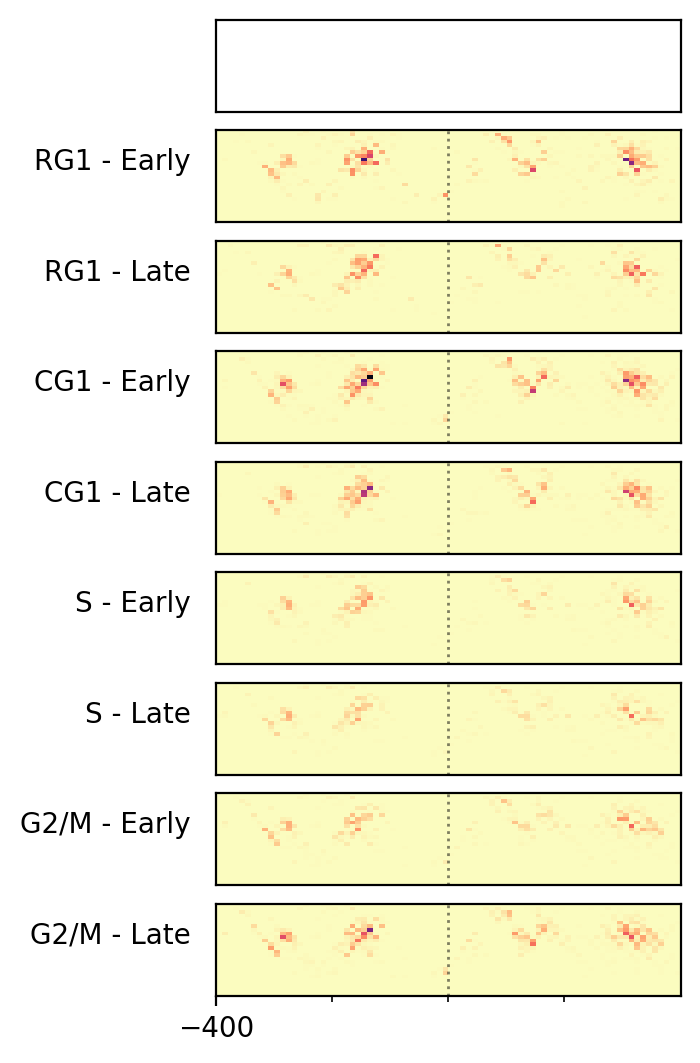

In [16]:
fig = analysis.plot_deconvolved_result(analysis.tf_mnase, mnase_span=(-padding, padding),
                                      figsize=(3, 6), vmax=30)


In [19]:
padding = 400
analysis.load_stacked_mnase_data_for_rossi_sites(tf_binding_sites.filtered_tf_sites,
    padding=padding)

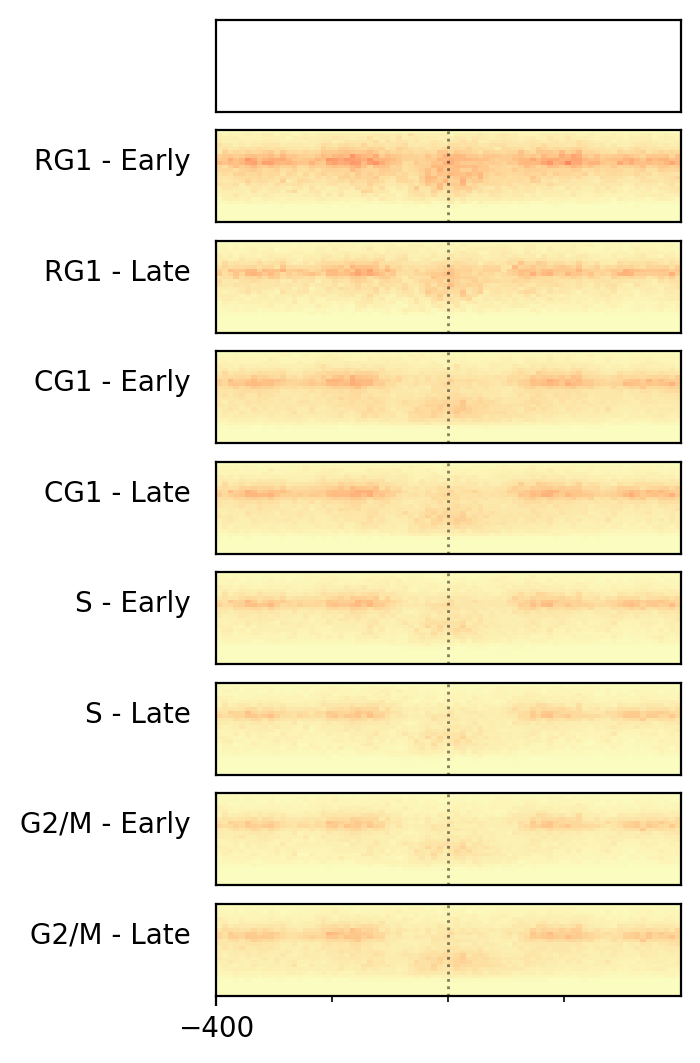

In [20]:
fig = analysis.plot_deconvolved_result(analysis.all_tfs_mnase, 
    mnase_span=(-padding, padding), figsize=(3, 6), vmax=10)

In [38]:
from src.cluster_tf_sites import TFClustering

tf_clustering = TFClustering()

In [39]:
tf_clustering.compute_tf_distances(analysis)

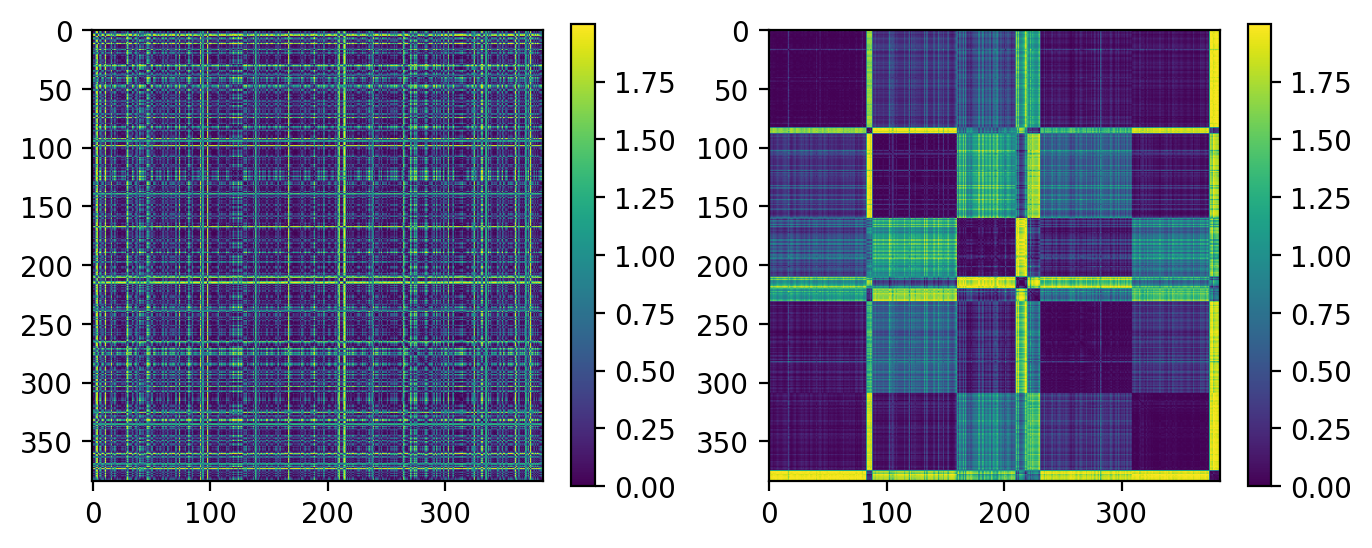

In [64]:
tf_clustering.plot_distance_mat()

In [70]:
tf_clustering.cluster_tfs(n_clusters=9, filtered_tf_sites=tf_binding_sites.filtered_tf_sites)

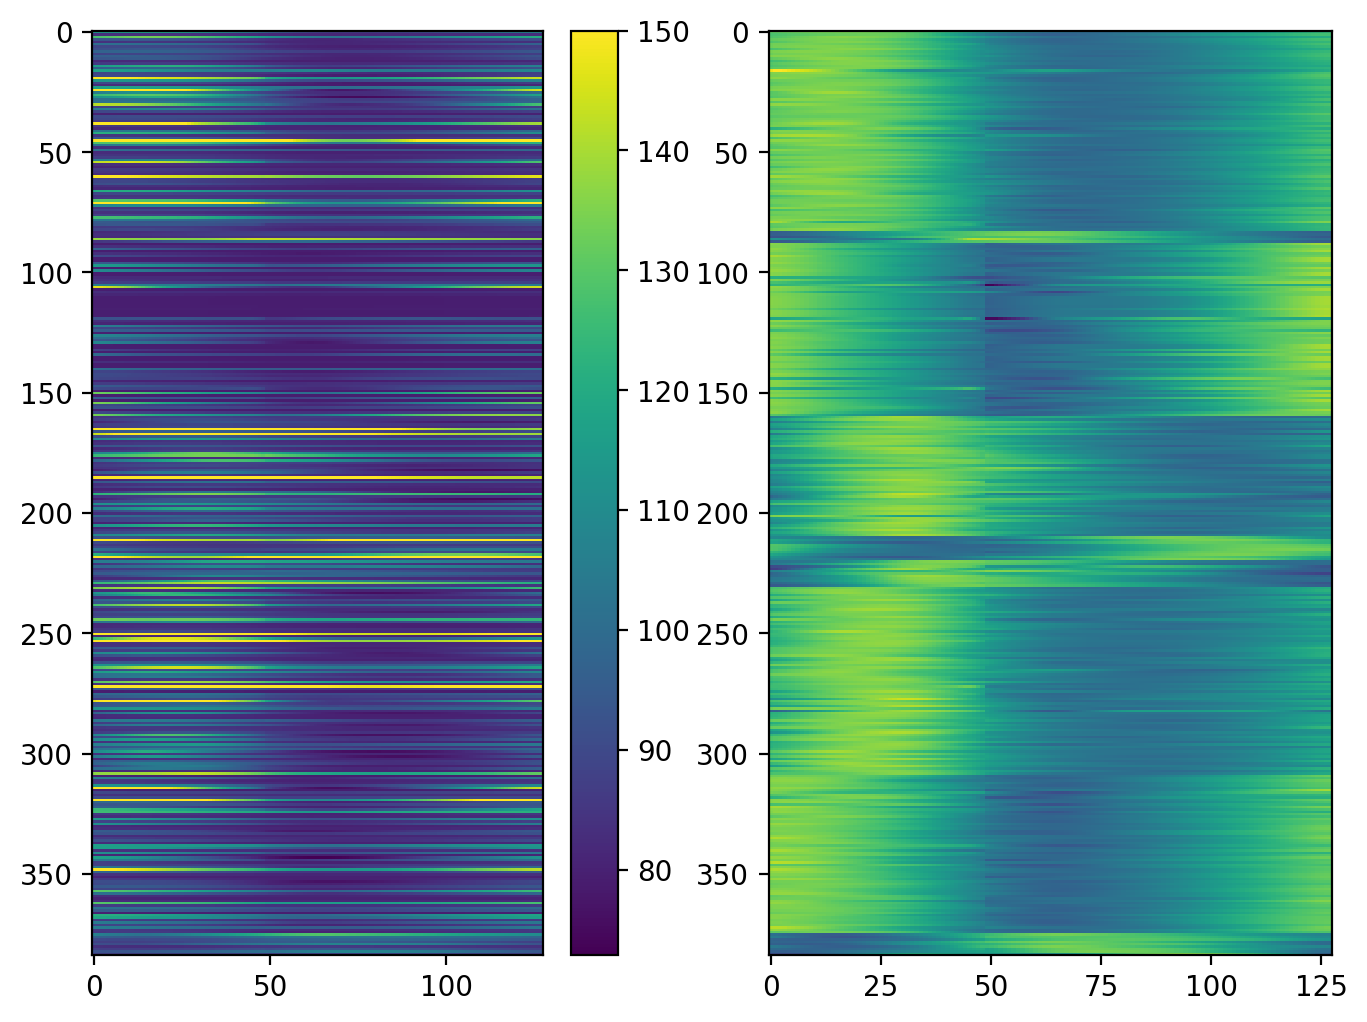

In [71]:
tf_clustering.plot_clusters()

Cluster 0
Cluster 1
Cluster 2
Cluster 3
Cluster 4
Cluster 5
Cluster 6
Cluster 7
Cluster 8


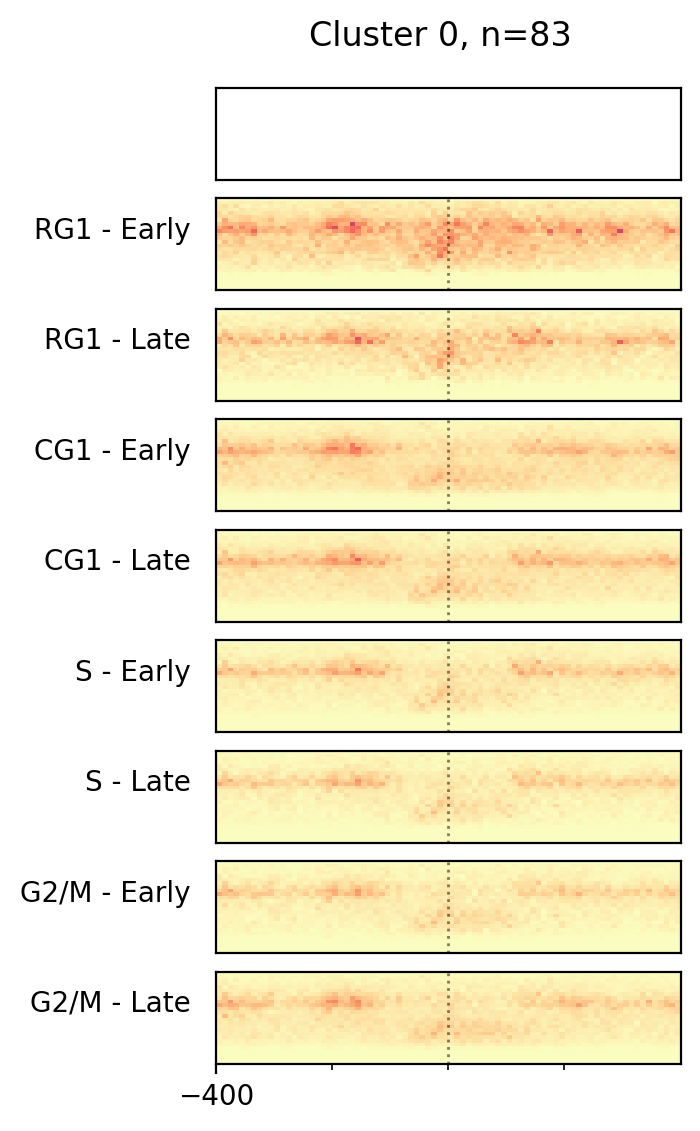

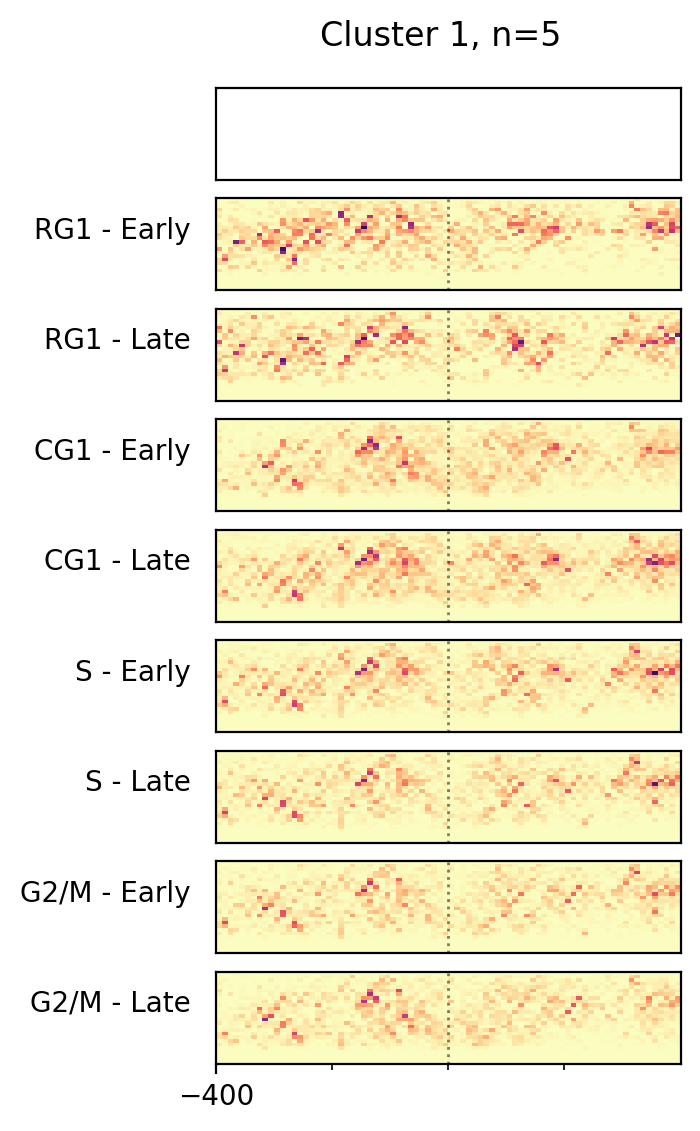

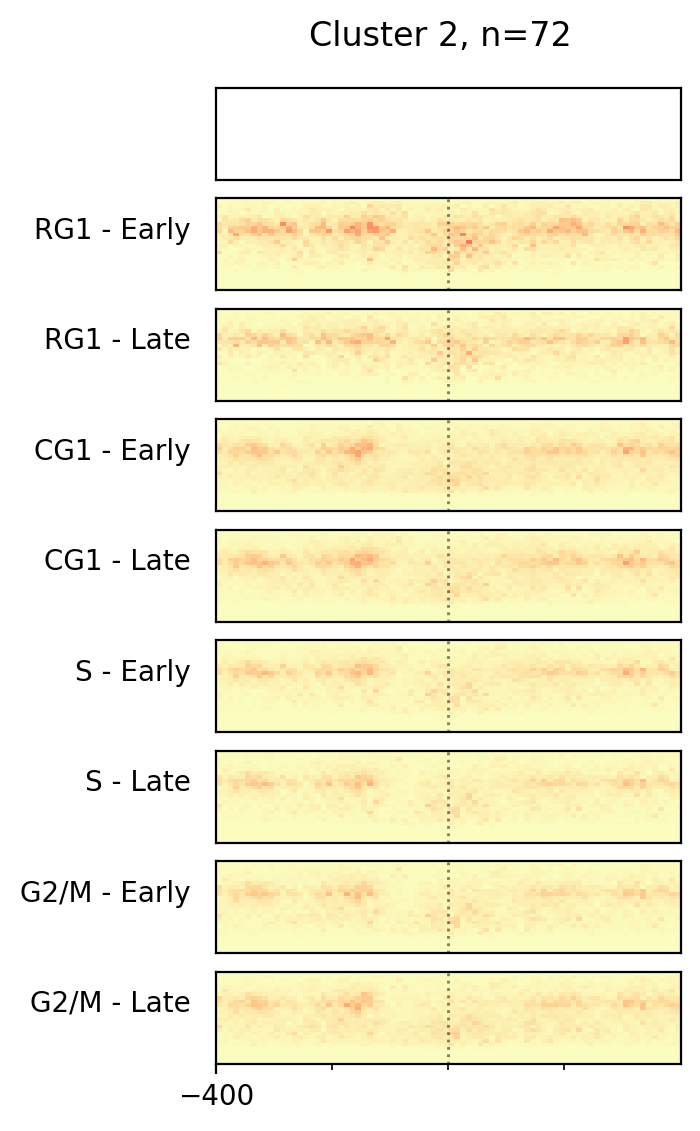

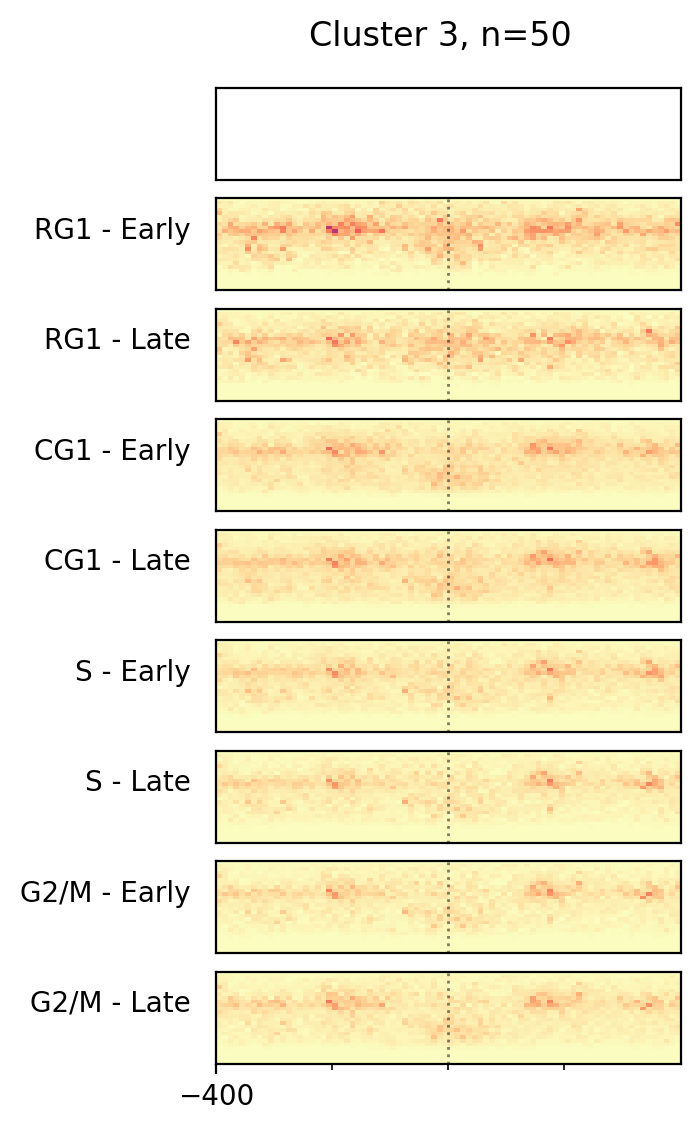

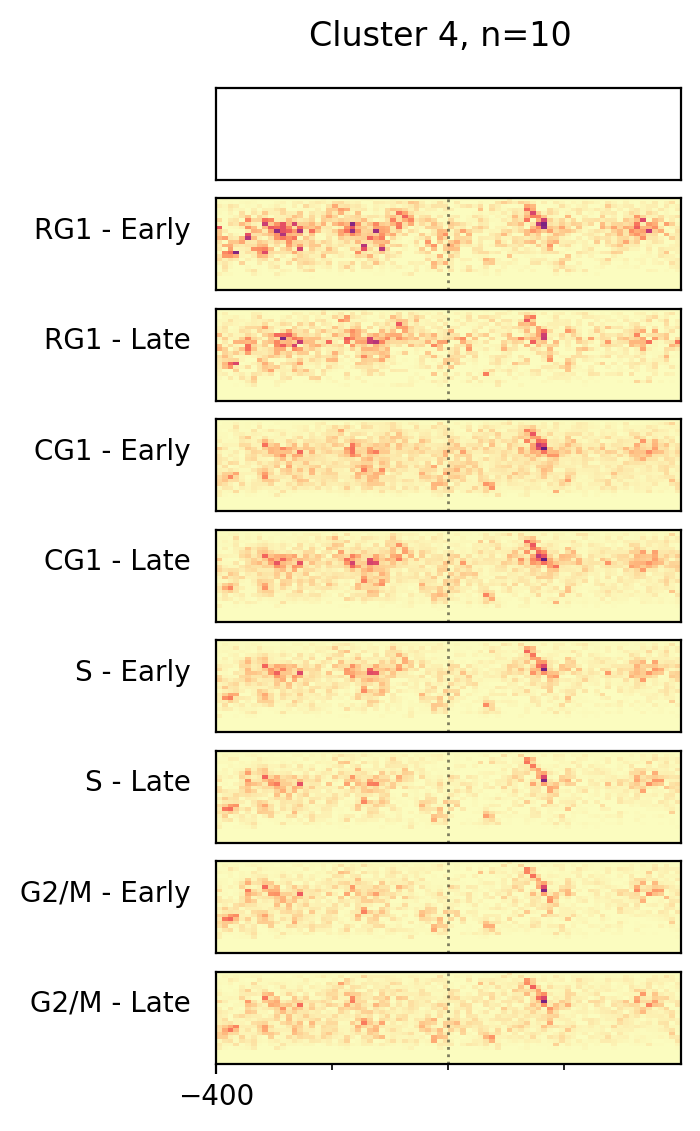

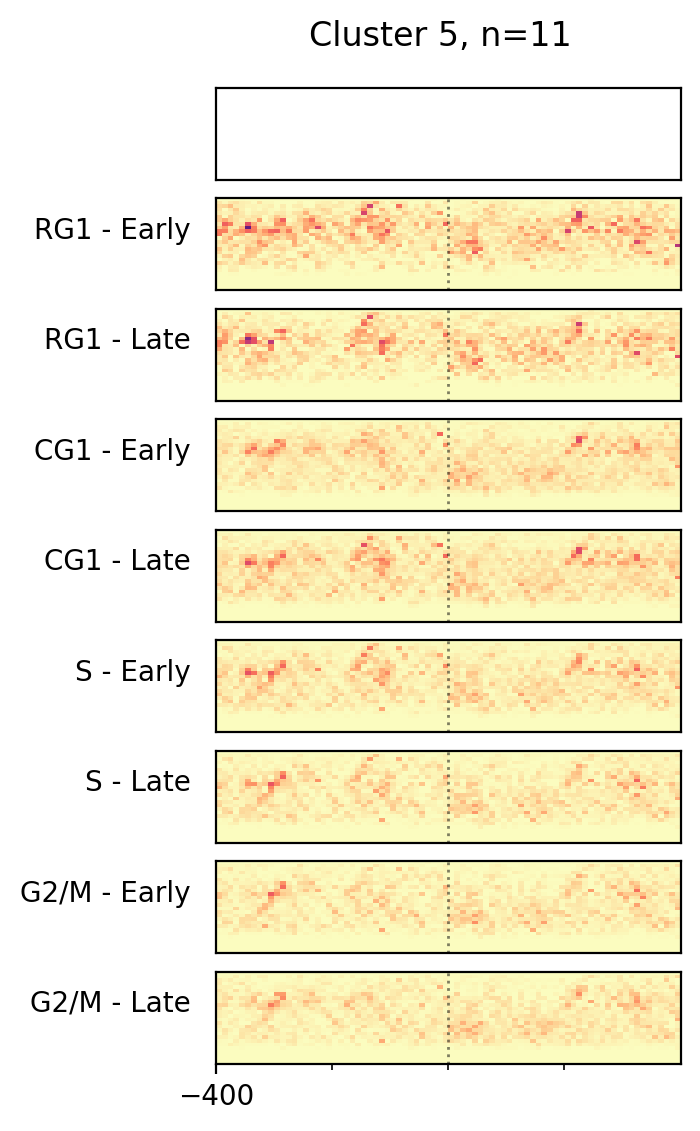

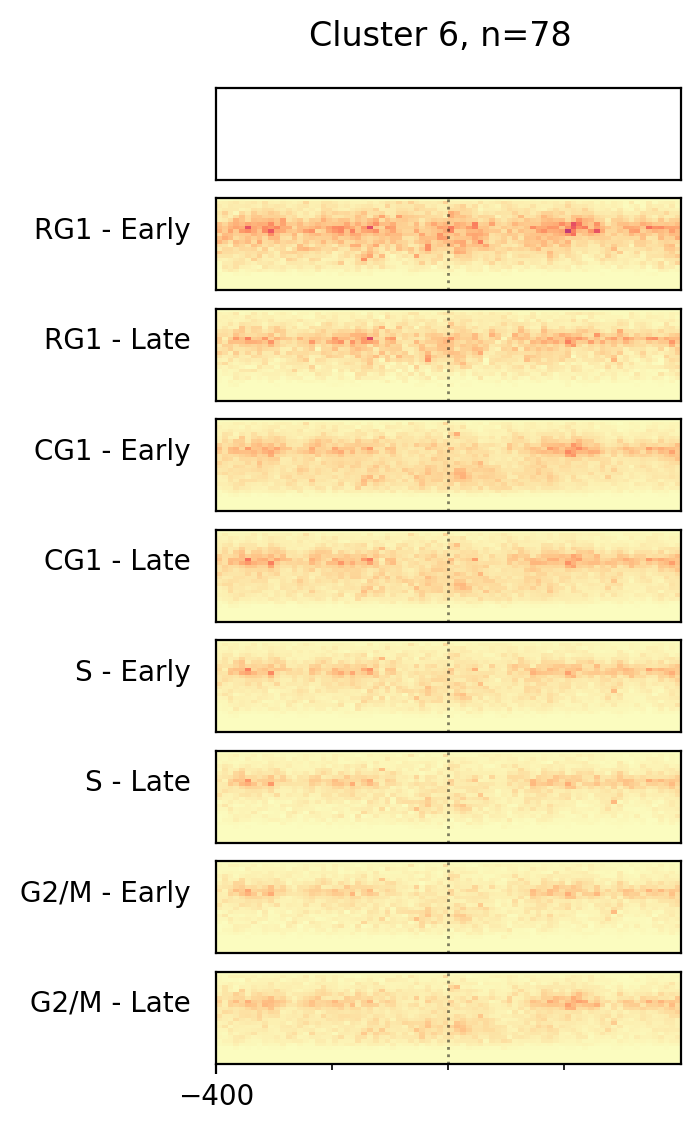

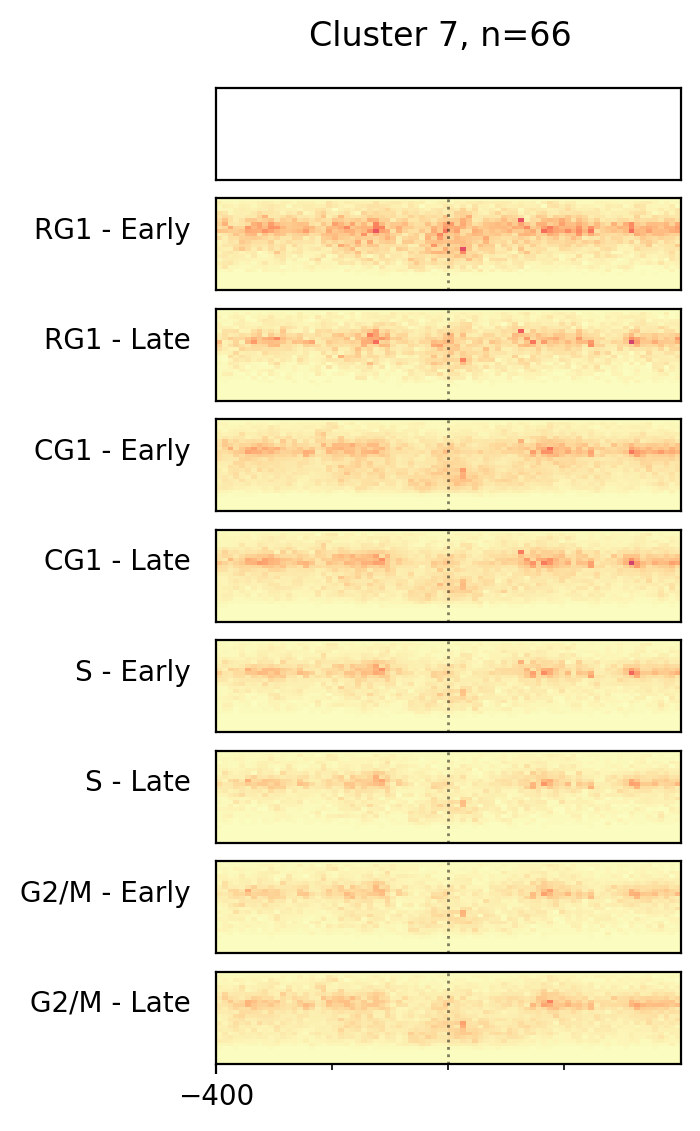

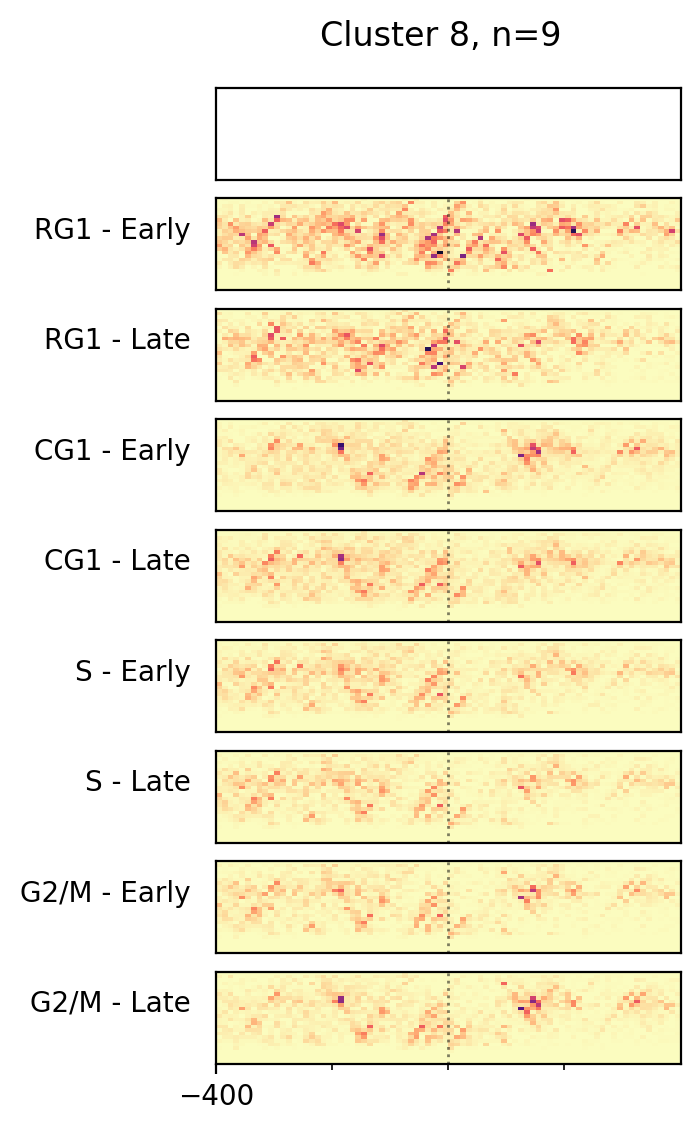

In [73]:
tf_clustering.plot_cluster_heatmaps(analysis)
